In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/[2024-2025] AN2DL

Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL


In [3]:
import pickle

with open("sli_final_dataset_X.pkl", 'rb') as f:
    dataset_X_wd = pickle.load(f)

with open("sli_final_dataset_Y.pkl", 'rb') as f:
    dataset_Y = pickle.load(f)

In [4]:
dataset_X = []

for seq in dataset_X_wd:
    new_seq = []
    for event in seq:
        if len(event) > 22:
            new_event = event[:22] + event[23:]
        else:
            new_event = event.copy()
        new_seq.append(new_event)
    dataset_X.append(new_seq)

print(len(dataset_X[0][0]))

101


In [6]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Masking,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------
# 1. Prepare the data
# ----------------------------

# Convert to numpy-friendly format
X = dataset_X
y = np.array(dataset_Y)

# Pad sequences to max length (30)
# Shape after padding: (num_samples, 30, 101)
X_padded = pad_sequences(
    X,
    maxlen=30,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0
)

# ----------------------------
# 2. Build the LSTM model
# ----------------------------

input_layer = Input(shape=(30, 101))

# Mask padded timesteps (zeros)
x = Masking(mask_value=0.0)(input_layer)

# LSTM layers
x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.3)(x)

x = LSTM(64)(x)
x = Dropout(0.3)(x)

# Fully connected layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=input_layer, outputs=output)

# ----------------------------
# 3. Compile the model
# ----------------------------

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ----------------------------
# 4. Train the model
# ----------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_padded,
    y,
    validation_split=0.2,
    epochs=250,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------
# 5. Evaluate
# ----------------------------

loss, accuracy = model.evaluate(X_padded, y, verbose=0)
print(f"Final accuracy: {accuracy:.4f}")



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 30, 101)   │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 30, 101)   │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 30)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 128)   │    117,760 │ masking_1[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 128)   │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ dropout_3[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 171,393 (669.50 KB)

 Trainable params: 171,393 (669.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8368 - loss: 0.4068 - val_accuracy: 0.8683 - val_loss: 0.2930
Epoch 2/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8775 - loss: 0.2733 - val_accuracy: 0.8715 - val_loss: 0.2799
Epoch 3/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8762 - loss: 0.2724 - val_accuracy: 0.8717 - val_loss: 0.2782
Epoch 4/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8721 - loss: 0.2734 - val_accuracy: 0.8711 - val_loss: 0.2715
Epoch 5/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8778 - loss: 0.2653 - val_accuracy: 0.8728 - val_loss: 0.2724
Epoch 6/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8752 - loss: 0.2723 - val_accuracy: 0.8733 - val_loss: 0.2695
Epoch 7/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8764 - loss: 0.2641 - val_accuracy: 0.8724 - val_loss: 0.2678
Epoch 8/250
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8724 - loss: 0.2719 -

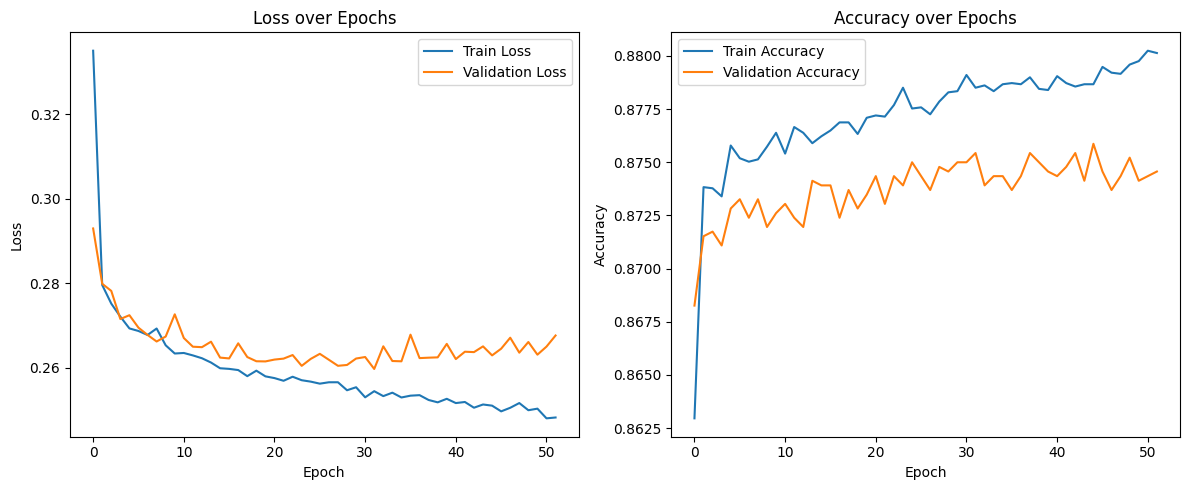

Final accuracy: 0.8784
Model saved as final_lstm_model.h5


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# ----------------------------
# 6. Evaluate the model
# ----------------------------

loss, accuracy = model.evaluate(X_padded, y, verbose=0)
print(f"Final accuracy: {accuracy:.4f}")

# ----------------------------
# 7. Save the model
# ----------------------------

model.save('final_lstm_model.h5')
print("Model saved as final_lstm_model.h5")


In [8]:
model.save('final_lstm.keras')